# A12 — Density Matrices, Mixed States, Noise Channels

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook; every matrix, every channel and every partial trace is built by hand.

---

## The one-sentence version

A state vector can only describe a system you know everything about. A **density
matrix** describes one you don't — and once you can write down "I don't know",
you can finally write down what noise *does*.

## The single most-confused point in the subject

Here are two coins on a table, and you must tell them apart.

- **Coin A** is a qubit in the superposition $|+\rangle = \tfrac{1}{\sqrt2}(|0\rangle + |1\rangle)$.
- **Coin B** is a qubit that a lab assistant prepared as $|0\rangle$ or $|1\rangle$
  by flipping a fair coin, and then refused to tell you which.

Measure either one in the computational basis and you get 0 half the time and 1
half the time. Take a billion shots. They are *identical*.

They are not the same state.

Coin A is one definite thing — a vector, fully known, with a relative phase you
could go and measure. Coin B is a **probability distribution over two definite
things**, and the "half" in it is your own ignorance, the same kind of half that
is in a shuffled deck. Coin A is quantum indeterminacy; Coin B is a filing error.

The reason people confuse them is that the computational-basis statistics are a
perfect disguise. **Figure 1 rips the disguise off** by asking a different
question, and the two answers come apart completely.

## Why we need a new object

You cannot write Coin B as a state vector at all. There is no $\alpha, \beta$ with
$|\alpha|^2 = |\beta|^2 = \tfrac12$ that behaves like it — every such vector is a
superposition with *some* definite relative phase, and Coin B has none. So we need
a bigger container:

$$\rho \;=\; \sum_i p_i\,|\psi_i\rangle\langle\psi_i|,
\qquad p_i \ge 0,\quad \sum_i p_i = 1.$$

That is the **density matrix**. A pure state is the special case with a single
$p_i = 1$, where $\rho = |\psi\rangle\langle\psi|$. Everything else is **mixed**.

And this is what earns us the *interior* of the Bloch sphere. A02 drew the
surface, which is exactly the set of pure states. This notebook fills it in: the
**Bloch ball**, where distance from the centre measures how much you know, and a
noise channel is a picture — a squashing, shrinking, sliding deformation of that
ball.

## What we build

1. $\rho$ from first principles; the Born rule in *any* basis, as $\langle k|\rho|k\rangle$.
2. The superposition-vs-mixture confrontation (Figure 1) — the whole point.
3. Bloch vector, **purity** $\mathrm{Tr}(\rho^2)$ and **von Neumann entropy**, and
   the ball they fill (Figure 2).
4. **Kraus operators** by hand, with the completeness relation
   $\sum_k K_k^\dagger K_k = I$ checked numerically (Figure 3).
5. **A channel as a deformation of the ball** (Figure 4) — depolarizing,
   amplitude damping, phase damping, as a small multiple over strength.
6. Decoherence under repeated application (Figure 5), and why amplitude damping
   ends *pure* while depolarizing does not.
7. **Partial trace**, and entanglement's fingerprint: half a Bell state is the
   dead centre of the ball (Figure 6).

In [1]:
from qviz import backends, bloch, grid, style

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A12")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

KET0 = np.array([1, 0], dtype=complex)
KET1 = np.array([0, 1], dtype=complex)
PLUS = np.array([1, 1], dtype=complex) / np.sqrt(2)
MINUS = np.array([1, -1], dtype=complex) / np.sqrt(2)
KET_PI = np.array([1, 1j], dtype=complex) / np.sqrt(2)     # |+i>
KET_MI = np.array([1, -1j], dtype=complex) / np.sqrt(2)    # |-i>

seed: 20260816


## Building $\rho$, and what it has to satisfy

$|\psi\rangle\langle\psi|$ is an **outer product**: a column vector times a row
vector, giving a matrix. In NumPy that is `np.outer(psi, psi.conj())`.

A legal density matrix is exactly a matrix that is

1. **Hermitian**, $\rho^\dagger = \rho$ — so its eigenvalues are real;
2. **positive semidefinite**, $\rho \succeq 0$ — no negative eigenvalues, because
   the eigenvalues are the probabilities in the mixture;
3. **unit trace**, $\mathrm{Tr}\,\rho = 1$ — the probabilities sum to one.

Those three conditions are the whole definition. Nothing else about $\rho$ is
assumed anywhere in this notebook.

**The Born rule generalises beautifully.** For a pure state we had
$P(k) = |\langle k|\psi\rangle|^2$. For a density matrix it is

$$P(k) \;=\; \langle k|\rho|k\rangle,$$

the diagonal entry of $\rho$ in the measurement basis. Change basis, and the
off-diagonal entries — the **coherences** — move onto the diagonal and start
showing up in the statistics. That single fact is why Figure 1 works.

In [2]:
def dm(psi):
    """Density matrix of a pure state: |psi><psi|."""
    psi = np.asarray(psi, dtype=complex).ravel()
    psi = psi / np.linalg.norm(psi)
    return np.outer(psi, psi.conj())


def mix(weights, states):
    """A classical mixture: sum_i p_i |psi_i><psi_i|."""
    w = np.asarray(weights, dtype=float)
    assert np.all(w >= -1e-15) and np.isclose(w.sum(), 1.0), "not a distribution"
    return sum(p * dm(s) for p, s in zip(w, states))


def is_density_matrix(rho, tol=1e-12):
    """The three defining conditions, checked rather than assumed."""
    herm = np.allclose(rho, rho.conj().T, atol=tol)
    psd = bool(np.min(np.linalg.eigvalsh(rho)) > -tol)
    unit = bool(abs(np.trace(rho).real - 1.0) < tol
                and abs(np.trace(rho).imag) < tol)
    return herm and psd and unit


def probs_in_basis(rho, basis):
    """Born rule in an arbitrary orthonormal basis: P(k) = <k|rho|k>."""
    return np.array([float((np.vdot(b, rho @ b)).real) for b in basis])


Z_BASIS = [KET0, KET1]
X_BASIS = [PLUS, MINUS]
Y_BASIS = [KET_PI, KET_MI]

RHO_SUP = dm(PLUS)                                   # Coin A: superposition
RHO_MIX = mix([0.5, 0.5], [KET0, KET1])              # Coin B: ignorance

print("superposition |+><|+| =")
print(np.round(RHO_SUP.real, 4))
print()
print("mixture 0.5|0><0| + 0.5|1><1| =")
print(np.round(RHO_MIX.real, 4))
print()
for name, r in [("superposition", RHO_SUP), ("mixture", RHO_MIX)]:
    print(f"{name:>14}  legal density matrix: {is_density_matrix(r)}   "
          f"eigenvalues: {np.round(np.linalg.eigvalsh(r), 6)}")
print()
print(f"{'':>14}  {'P(0)':>7} {'P(1)':>7}   {'P(+)':>7} {'P(-)':>7}")
for name, r in [("superposition", RHO_SUP), ("mixture", RHO_MIX)]:
    pz = probs_in_basis(r, Z_BASIS)
    px = probs_in_basis(r, X_BASIS)
    print(f"{name:>14}  {pz[0]:7.3f} {pz[1]:7.3f}   {px[0]:7.3f} {px[1]:7.3f}")

superposition |+><|+| =
[[0.5 0.5]
 [0.5 0.5]]

mixture 0.5|0><0| + 0.5|1><1| =
[[0.5 0. ]
 [0.  0.5]]

 superposition  legal density matrix: True   eigenvalues: [0. 1.]
       mixture  legal density matrix: True   eigenvalues: [0.5 0.5]

                   P(0)    P(1)      P(+)    P(-)
 superposition    0.500   0.500     1.000   0.000
       mixture    0.500   0.500     0.500   0.500


There it is, in the last two lines of output. Identical in $Z$. Completely
different in $X$: the superposition gives $|+\rangle$ **every single time**, and
the mixture is a coin flip.

The matrices show you why. The superposition has $\tfrac12$ in all four entries;
the mixture has $\tfrac12$ on the diagonal and **zero off-diagonal**. Those
off-diagonal entries are the coherences, and they are the difference between "in
superposition" and "unknown". Decoherence — the thing noise does — is literally
the process of those corners shrinking to zero.

## Figure 1 — the confrontation

Four columns, two rows. Top row is the superposition, bottom row is the
50/50 mixture.

- **Column 1** is $\rho$ itself, drawn as a heatmap of its (real) entries.
- **Column 2** is the $Z$ measurement — the question everybody asks.
- **Column 3** is the $X$ measurement — the question that tells them apart.
- **Column 4** is a slice through the Bloch ball (the $x$–$z$ plane), where the
  superposition sits on the surface and the mixture sits at the dead centre.

Column 2 is the disguise. Column 3 is the reveal. Column 1 is the mechanism.
Column 4 is the geometry we spend the rest of the notebook in.

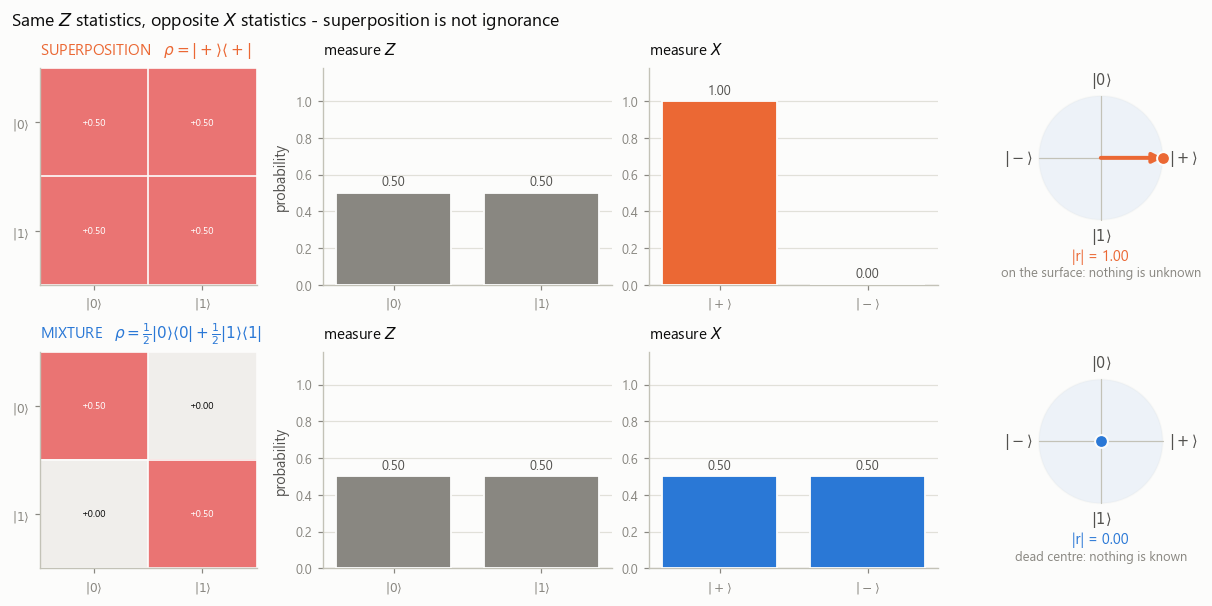

In [3]:
def bloch_vector(rho):
    """r = (Tr(rho X), Tr(rho Y), Tr(rho Z)) - real by Hermiticity of rho."""
    return np.array([np.trace(rho @ P).real for P in (X, Y, Z)])


KETLAB = [r"$|0\rangle$", r"$|1\rangle$"]


def disc(ax, r, color, tag, note=None):
    """The x-z slice of the Bloch ball, with one state marked."""
    ax.add_patch(plt.Circle((0, 0), 1.0, facecolor=style.BLUE, alpha=0.07,
                            edgecolor=style.AXIS, lw=1.1, zorder=1))
    ax.plot([-1, 1], [0, 0], color=style.AXIS, lw=0.8, zorder=2)
    ax.plot([0, 0], [-1, 1], color=style.AXIS, lw=0.8, zorder=2)
    for pos, lab, ha, va in [((0, 1.10), r"$|0\rangle$", "center", "bottom"),
                             ((0, -1.10), r"$|1\rangle$", "center", "top"),
                             ((1.10, 0), r"$|+\rangle$", "left", "center"),
                             ((-1.10, 0), r"$|-\rangle$", "right", "center")]:
        ax.text(pos[0], pos[1], lab, ha=ha, va=va, fontsize=9.5,
                color=style.INK_2, zorder=5)
    ax.annotate("", xy=(r[0], r[2]), xytext=(0, 0), zorder=4,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=2.6,
                                shrinkA=0, shrinkB=0, mutation_scale=13))
    ax.scatter([r[0]], [r[2]], s=70, color=color, edgecolors=style.SURFACE,
               linewidths=1.3, zorder=6)
    ax.text(0.0, -1.58, tag, ha="center", va="center", fontsize=9.5,
            color=color, zorder=5)
    if note:
        ax.text(0.0, -1.86, note, ha="center", va="center", fontsize=8.5,
                color=style.MUTED, zorder=5)
    ax.set_xlim(-1.62, 1.62)
    ax.set_ylim(-2.05, 1.45)
    ax.set_aspect("equal")
    ax.axis("off")


rows = [("SUPERPOSITION", RHO_SUP, style.ORANGE,
         r"$\rho=|+\rangle\langle+|$"),
        ("MIXTURE", RHO_MIX, style.BLUE,
         r"$\rho=\frac{1}{2}|0\rangle\langle0|+\frac{1}{2}|1\rangle\langle1|$")]

fig = plt.figure(figsize=(11.4, 5.4))
gs = fig.add_gridspec(2, 4, width_ratios=[0.80, 1.0, 1.0, 1.06])

for i, (name, rho, col, tex) in enumerate(rows):
    axm = fig.add_subplot(gs[i, 0])
    grid.matrix(axm, rho, part="re", cbar=False, vmax=1.0, fmt="{:+.2f}",
                hide_zeros=False, labels=KETLAB)
    axm.set_title(f"{name}   {tex}", loc="left", fontsize=10, color=col)

    pz = probs_in_basis(rho, Z_BASIS)
    px = probs_in_basis(rho, X_BASIS)

    axz = fig.add_subplot(gs[i, 1])
    grid.prob_bars(axz, pz, labels=["0", "1"], color=style.MUTED)
    axz.set_ylim(0, 1.18)
    axz.set_title("measure $Z$", loc="left", fontsize=10)

    axx = fig.add_subplot(gs[i, 2])
    grid.prob_bars(axx, px, labels=["+", "-"], color=col)
    axx.set_ylim(0, 1.18)
    axx.set_ylabel("")
    axx.set_title("measure $X$", loc="left", fontsize=10)

    for ax, p in [(axz, pz), (axx, px)]:
        for k, v in enumerate(p):
            ax.text(k, v + 0.04, f"{v:.2f}", ha="center", fontsize=8.5,
                    color=style.INK_2)

    r = bloch_vector(rho)
    axd = fig.add_subplot(gs[i, 3])
    note = ("on the surface: nothing is unknown" if np.linalg.norm(r) > 0.5
            else "dead centre: nothing is known")
    disc(axd, r, col, f"|r| = {np.linalg.norm(r):.2f}", note)

fig.suptitle("Same $Z$ statistics, opposite $X$ statistics - "
             "superposition is not ignorance",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

Read column 3 twice. The superposition is an **eigenstate** of $X$: measuring
$X$ returns $+1$ with probability 1, deterministically, forever. The mixture
returns $\pm1$ at random. A single well-chosen measurement separates two states
that a billion $Z$ measurements could not.

That is also the practical answer to "how do you know a quantum computer is doing
something quantum?" — you measure in a basis where coherence has nowhere to hide.

## A trap worth stepping in on purpose: $\rho$ forgets the recipe

$\rho$ is not a record of how the state was prepared. It is the *complete*
description of the state, and different preparations that lead to the same $\rho$
are **physically indistinguishable by any measurement whatsoever**.

The classic example: a 50/50 mixture of $|0\rangle$ and $|1\rangle$, and a 50/50
mixture of $|+\rangle$ and $|-\rangle$, are the same state.

In [4]:
rho_z_recipe = mix([0.5, 0.5], [KET0, KET1])
rho_x_recipe = mix([0.5, 0.5], [PLUS, MINUS])
rho_y_recipe = mix([0.5, 0.5], [KET_PI, KET_MI])

print("50/50 of |0>,|1>   ->"); print(np.round(rho_z_recipe.real, 6))
print("50/50 of |+>,|->   ->"); print(np.round(rho_x_recipe.real, 6))
print("50/50 of |+i>,|-i> ->"); print(np.round(rho_y_recipe.real, 6))
print()
print("all three identical? ",
      np.allclose(rho_z_recipe, rho_x_recipe),
      np.allclose(rho_z_recipe, rho_y_recipe))
print("and all equal to I/2? ", np.allclose(rho_z_recipe, I2 / 2))

# A lopsided mixture of two NON-orthogonal states reproduced as an orthogonal one.
tilted = mix([0.75, 0.25], [KET0, PLUS])
vals, vecs = np.linalg.eigh(tilted)
print()
print("a 75/25 mixture of the non-orthogonal |0>, |+> has eigen-decomposition")
print("  weights", np.round(vals[::-1], 4), "on its own eigenvectors,")
print("  which is a DIFFERENT recipe for the very same rho:",
      np.allclose(mix(vals[::-1], [vecs[:, 1], vecs[:, 0]]), tilted))

50/50 of |0>,|1>   ->
[[0.5 0. ]
 [0.  0.5]]
50/50 of |+>,|->   ->
[[0.5 0. ]
 [0.  0.5]]
50/50 of |+i>,|-i> ->
[[0.5 0. ]
 [0.  0.5]]

all three identical?  True True
and all equal to I/2?  True

a 75/25 mixture of the non-orthogonal |0>, |+> has eigen-decomposition
  weights [0.8953 0.1047] on its own eigenvectors,
  which is a DIFFERENT recipe for the very same rho: True


So "the qubit is *really* either $|0\rangle$ or $|1\rangle$, we just don't know
which" is not a statement about the state — it is one of infinitely many stories
you could tell about $I/2$, and no experiment can favour it. This is worth holding
onto when you meet interpretations of quantum mechanics.

## The Bloch ball: distance from the centre is how much you know

Any $2\times2$ Hermitian matrix can be written in the Pauli basis, and unit trace
fixes the identity coefficient:

$$\rho \;=\; \tfrac12\big(I + r_x X + r_y Y + r_z Z\big),
\qquad r_i = \mathrm{Tr}(\rho\,\sigma_i).$$

$r$ is the **Bloch vector**, and it is *exactly* the vector A02 drew — but now it
is allowed to be short. Positivity, $\rho \succeq 0$, works out to precisely

$$|r| \le 1.$$

The sphere A02 drew was only the boundary. The physical states are the whole
**ball**.

Two numbers measure where you are in it.

**Purity** $\ \mathcal{P} = \mathrm{Tr}(\rho^2)$. For a pure state $\rho^2 = \rho$
so $\mathcal{P} = 1$; the minimum is $1/d = \tfrac12$ at the centre. In one line
of algebra,

$$\mathrm{Tr}(\rho^2) = \tfrac{1 + |r|^2}{2}.$$

**Von Neumann entropy** $\ S(\rho) = -\mathrm{Tr}(\rho\log_2\rho)
= -\sum_i \lambda_i \log_2 \lambda_i$ over the eigenvalues. This is the Shannon
entropy of the eigenvalue distribution: $0$ bits on the surface (you know
everything), $1$ bit at the centre (you know nothing at all).

Both are functions of $|r|$ alone, and Figure 2 confirms that numerically rather
than taking my word for it.

In [5]:
def rho_from_bloch(r):
    """Inverse map: rho = (I + r.sigma)/2."""
    x, y, z = r
    return 0.5 * (I2 + x * X + y * Y + z * Z)


def purity(rho):
    return float(np.trace(rho @ rho).real)


def entropy(rho, tol=1e-12):
    """von Neumann entropy in BITS. 0 log 0 is taken as 0.

    Clamped at 0: entropy is non-negative by definition, and a pure state
    otherwise comes out at -1e-17 and prints as "-0.00", which reads as a bug.
    """
    lam = np.linalg.eigvalsh(rho).real
    lam = lam[lam > tol]
    return float(max(0.0, -np.sum(lam * np.log2(lam))))


def haar_qubit(rng):
    v = rng.normal(size=2) + 1j * rng.normal(size=2)
    return v / np.linalg.norm(v)


def random_mixture(rng):
    """An honest mixture: two random pure states, a random weight."""
    w = rng.random()
    return mix([w, 1 - w], [haar_qubit(rng), haar_qubit(rng)])


print(f"{'state':>26} {'|r|':>7} {'Tr(rho^2)':>10} {'S (bits)':>9}")
named = [("|0><0|  (pure)", dm(KET0)),
         ("|+><+|  (pure)", dm(PLUS)),
         ("0.9|0>+0.1|1> mixture", mix([0.9, 0.1], [KET0, KET1])),
         ("0.7|0>+0.3|1> mixture", mix([0.7, 0.3], [KET0, KET1])),
         ("I/2  (maximally mixed)", I2 / 2)]
for name, rho in named:
    r = bloch_vector(rho)
    print(f"{name:>26} {np.linalg.norm(r):7.3f} {purity(rho):10.4f} "
          f"{entropy(rho):9.4f}")

# The round trip, and the closed form for purity, on random states.
worst_rt, worst_pu = 0.0, 0.0
for _ in range(500):
    rho = random_mixture(rng)
    r = bloch_vector(rho)
    worst_rt = max(worst_rt, np.max(np.abs(rho_from_bloch(r) - rho)))
    worst_pu = max(worst_pu,
                   abs(purity(rho) - (1 + np.linalg.norm(r) ** 2) / 2))
print()
print(f"rho -> r -> rho  worst error over 500 random states: {worst_rt:.2e}")
print(f"Tr(rho^2) vs (1+|r|^2)/2   worst error:              {worst_pu:.2e}")

                     state     |r|  Tr(rho^2)  S (bits)
            |0><0|  (pure)   1.000     1.0000    0.0000
            |+><+|  (pure)   1.000     1.0000    0.0000
     0.9|0>+0.1|1> mixture   0.800     0.8200    0.4690
     0.7|0>+0.3|1> mixture   0.400     0.5800    0.8813
    I/2  (maximally mixed)   0.000     0.5000    1.0000



rho -> r -> rho  worst error over 500 random states: 2.50e-16
Tr(rho^2) vs (1+|r|^2)/2   worst error:              5.55e-16


## Figure 2 — the ball

Four hundred and fifty random mixtures, each one two random pure states blended
with a random weight, plotted at their Bloch vectors and coloured by purity.

They fill a **ball**. Not a sphere with a hollow inside, not a cloud with
outliers — a solid ball whose surface is exactly the pure states A02 drew, and
whose centre is total ignorance. The two right-hand panels show the same points
against the closed forms: purity and entropy depend on the radius and on
*nothing else*.

The dark ring in the scatter at $|r| = 1$ is the pure states. Nothing is outside
it, and that is positivity.

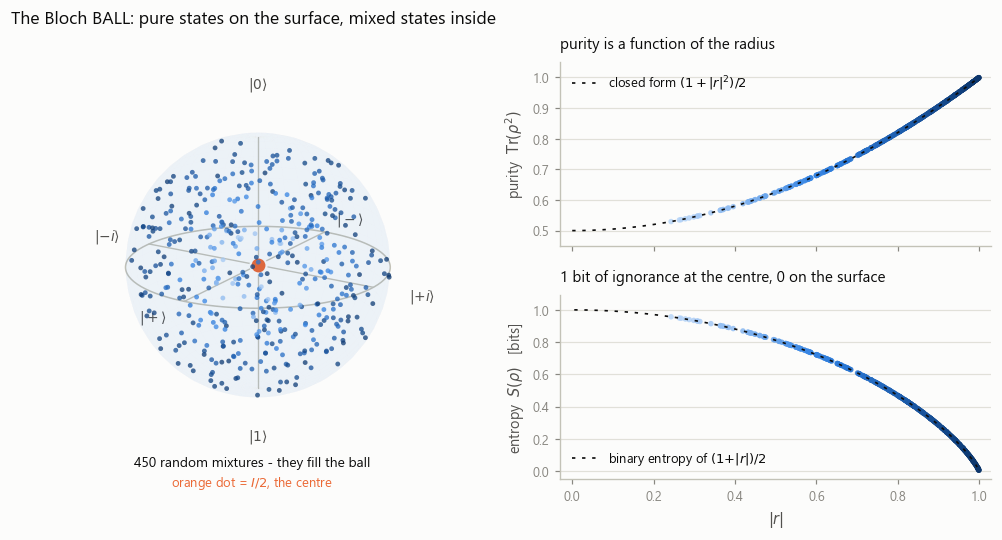

largest |r| over 450 random mixtures: 0.999102  (must be <= 1)
purity range: 0.5295 .. 0.9991   (theoretical floor 0.5)


In [6]:
def fill(ax, zoom=1.5):
    """Enlarge a Bloch panel inside its axes.

    mplot3d leaves a lot of slack around the data cube; without this call every
    3D panel reads as a postage stamp. Same helper A02 uses.
    """
    ax.set_box_aspect((1, 1, 1), zoom=zoom)
    return ax


N = 450
R = np.empty((N, 3))
PU = np.empty(N)
SV = np.empty(N)
for k in range(N):
    rho = random_mixture(rng)
    R[k] = bloch_vector(rho)
    PU[k] = purity(rho)
    SV[k] = entropy(rho)
RAD = np.linalg.norm(R, axis=1)

# The ball spans both rows: a 3D axis is sized by the SHORTER side of its cell,
# so height is what makes it big, and the two 2D panels stack beside it.
fig = plt.figure(figsize=(9.0, 4.8))
gs = fig.add_gridspec(2, 2, width_ratios=[1.12, 1])

ax = fig.add_subplot(gs[:, 0], projection="3d")
bloch.sphere(ax, alpha=0.035, wire=False)
fill(ax, 1.62)
ax.scatter(R[:, 0], R[:, 1], R[:, 2], c=PU, cmap=style.SEQ, vmin=0.5, vmax=1.0,
           s=10, depthshade=False, alpha=0.75, linewidths=0, zorder=5,
           rasterized=True)
ax.scatter([0], [0], [0], s=110, color=style.ORANGE, depthshade=False,
           edgecolors=style.SURFACE, linewidths=1.4, zorder=9)
bloch.label(ax, f"{N} random mixtures - they fill the ball", y=0.055)
bloch.label(ax, "orange dot = $I/2$, the centre", y=0.012, size=8.5,
            color=style.ORANGE)

axb = fig.add_subplot(gs[0, 1])
t = np.linspace(0, 1, 200)
axb.scatter(RAD, PU, s=13, c=PU, cmap=style.SEQ, vmin=0.5, vmax=1.0, alpha=0.8,
            linewidths=0, zorder=3, rasterized=True)
axb.plot(t, (1 + t ** 2) / 2, color=style.INK, lw=1.1, ls=(0, (2, 4)), zorder=4,
         label=r"closed form $(1+|r|^2)/2$")
axb.set_ylabel(r"purity  $\mathrm{Tr}(\rho^2)$")
axb.set_ylim(0.45, 1.05)
axb.set_xlim(-0.03, 1.03)
axb.set_xticklabels([])
axb.legend(loc="upper left")
axb.set_title("purity is a function of the radius", loc="left", fontsize=10)

axc = fig.add_subplot(gs[1, 1])
lam = (1 + t[1:-1]) / 2
s_closed = -(lam * np.log2(lam) + (1 - lam) * np.log2(1 - lam))
axc.scatter(RAD, SV, s=13, c=PU, cmap=style.SEQ, vmin=0.5, vmax=1.0, alpha=0.8,
            linewidths=0, zorder=3, rasterized=True)
axc.plot(t[1:-1], s_closed, color=style.INK, lw=1.1, ls=(0, (2, 4)), zorder=4,
         label="binary entropy of $(1{+}|r|)/2$")
axc.set_xlabel(r"$|r|$")
axc.set_ylabel(r"entropy  $S(\rho)$   [bits]")
axc.set_ylim(-0.05, 1.09)
axc.set_xlim(-0.03, 1.03)
axc.legend(loc="lower left")
axc.set_title("1 bit of ignorance at the centre, 0 on the surface", loc="left",
              fontsize=10)

fig.suptitle("The Bloch BALL: pure states on the surface, mixed states inside",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"largest |r| over {N} random mixtures: {RAD.max():.6f}  (must be <= 1)")
print(f"purity range: {PU.min():.4f} .. {PU.max():.4f}   "
      f"(theoretical floor 0.5)")

Notice the colour and the radius carry the same information — that is the point,
not a redundancy. In one qubit, "how mixed am I" is a single number, and the
picture spends its three dimensions on *direction* instead.

The scatter thins toward the centre because a blend of two random pure states
rarely lands near $I/2$: you need the two states to be nearly antipodal *and* the
weight near $\tfrac12$. Ignorance, it turns out, is hard to achieve by accident.
Noise achieves it on purpose, which is the rest of this notebook.

## Noise, properly: quantum channels and Kraus operators

A closed system evolves by a unitary: $\rho \mapsto U\rho U^\dagger$. That map
takes the surface of the ball to the surface — a rotation. It can never make a
pure state mixed, so **it can never describe noise**.

Real noise happens because the qubit is not closed: it leaks into an environment
you don't measure. Do the honest thing — evolve qubit *and* environment
unitarily, then trace the environment out — and what comes back is always of the
form

$$\mathcal{E}(\rho) \;=\; \sum_k K_k\,\rho\,K_k^\dagger,
\qquad \sum_k K_k^\dagger K_k = I.$$

The $K_k$ are the **Kraus operators** and this is the **operator-sum
representation**. The theorem behind it (Stinespring / Choi–Kraus) says the two
descriptions — "unitary on a bigger space, then forget part of it" and "a list of
matrices satisfying that sum rule" — are the same thing. We will take the
theorem; the sum rule we check by hand.

**Why the sum rule is exactly trace preservation.** One line:

$$\mathrm{Tr}\,\mathcal{E}(\rho) = \sum_k \mathrm{Tr}(K_k\rho K_k^\dagger)
= \mathrm{Tr}\Big(\big(\textstyle\sum_k K_k^\dagger K_k\big)\rho\Big)
= \mathrm{Tr}(\rho) = 1,$$

using cyclicity of the trace. Probabilities still sum to one. And the sandwich
form $K\rho K^\dagger$ is automatically positive, which is the **CP** in
**CPTP** — completely positive, trace preserving. Those two words are the whole
job description of a noise channel.

### The three channels

**Depolarizing** — with probability $p$, replace the qubit with $I/2$:

$$\mathcal{E}(\rho) = (1-p)\rho + p\,\tfrac{I}{2},
\qquad K = \Big\{\sqrt{1-\tfrac{3p}{4}}\,I,\ \sqrt{\tfrac{p}{4}}X,\
\sqrt{\tfrac{p}{4}}Y,\ \sqrt{\tfrac{p}{4}}Z\Big\}.$$

The Kraus form says the same thing differently: with probability $p/4$ each, apply
$X$, $Y$ or $Z$ and don't tell anyone. (Yes, four operators for what looks like
two outcomes — that mismatch is a hint that Kraus decompositions are not unique.)

**Amplitude damping** — energy loss, $|1\rangle \to |0\rangle$ with probability
$\gamma$. This is $T_1$:

$$K_0 = \begin{pmatrix}1 & 0\\ 0 & \sqrt{1-\gamma}\end{pmatrix},\qquad
K_1 = \begin{pmatrix}0 & \sqrt{\gamma}\\ 0 & 0\end{pmatrix}.$$

$K_1 = \sqrt{\gamma}\,|0\rangle\langle1|$ is the *jump*: the qubit emitted a
photon and fell to the ground state. Note this channel is **not symmetric** — it
has a direction, toward $|0\rangle$.

**Phase damping** — the environment learns *which* state you are in, without
taking any energy. This is pure dephasing, the $T_2$ part:

$$K_0 = \begin{pmatrix}1 & 0\\ 0 & \sqrt{1-\lambda}\end{pmatrix},\qquad
K_1 = \begin{pmatrix}0 & 0\\ 0 & \sqrt{\lambda}\end{pmatrix}.$$

Populations untouched, coherences shrunk. This is the channel that turns Coin A
into Coin B.

In [7]:
def apply_channel(kraus, rho):
    """rho -> sum_k K_k rho K_k^dagger."""
    return sum(K @ rho @ K.conj().T for K in kraus)


def completeness(kraus):
    """sum_k K_k^dagger K_k, which must be exactly the identity."""
    return sum(K.conj().T @ K for K in kraus)


def depolarizing(p):
    """With probability p, replace the qubit by I/2."""
    return [np.sqrt(1 - 3 * p / 4) * I2, np.sqrt(p / 4) * X,
            np.sqrt(p / 4) * Y, np.sqrt(p / 4) * Z]


def amplitude_damping(g):
    """|1> decays to |0> with probability g. The T1 channel."""
    return [np.array([[1, 0], [0, np.sqrt(1 - g)]], dtype=complex),
            np.array([[0, np.sqrt(g)], [0, 0]], dtype=complex)]


def phase_damping(lam):
    """Coherences shrink by sqrt(1-lam); populations untouched. Pure dephasing."""
    return [np.array([[1, 0], [0, np.sqrt(1 - lam)]], dtype=complex),
            np.array([[0, 0], [0, np.sqrt(lam)]], dtype=complex)]


CHANNELS = [("depolarizing", depolarizing, style.BLUE),
            ("amplitude damping", amplitude_damping, style.ORANGE),
            ("phase damping", phase_damping, style.AQUA)]

print("completeness  max|sum_k K_k^dag K_k - I|   over p = 0 .. 1")
for name, make, _ in CHANNELS:
    worst = max(np.max(np.abs(completeness(make(p)) - I2))
                for p in np.linspace(0, 1, 101))
    print(f"  {name:>18}: {worst:.3e}")

print()
print("trace preservation and positivity on 200 random inputs, p = 0.37")
for name, make, _ in CHANNELS:
    ks = make(0.37)
    bad = 0
    for _ in range(200):
        out = apply_channel(ks, random_mixture(rng))
        if not is_density_matrix(out, tol=1e-10):
            bad += 1
    print(f"  {name:>18}: {200 - bad}/200 outputs are legal density matrices")

# The depolarizing Kraus set really does reproduce the "replace with I/2" form.
p = 0.3
worst = 0.0
for _ in range(200):
    rho = random_mixture(rng)
    worst = max(worst, np.max(np.abs(
        apply_channel(depolarizing(p), rho) - ((1 - p) * rho + p * I2 / 2))))
print()
print(f"depolarizing Kraus form vs (1-p)rho + p I/2:  max error {worst:.2e}")

completeness  max|sum_k K_k^dag K_k - I|   over p = 0 .. 1
        depolarizing: 2.220e-16
   amplitude damping: 2.220e-16
       phase damping: 2.220e-16

trace preservation and positivity on 200 random inputs, p = 0.37


        depolarizing: 200/200 outputs are legal density matrices


   amplitude damping: 200/200 outputs are legal density matrices


       phase damping: 200/200 outputs are legal density matrices



depolarizing Kraus form vs (1-p)rho + p I/2:  max error 2.22e-16


## Figure 3 — the Kraus operators, and the sum rule

Each Kraus operator drawn as a **Hinton diagram**: the area of each square is the
magnitude of that matrix entry, and its colour is the phase (so $+1$ and $-1$ are
different hues, and $Y$'s $\pm i$ entries are different again). All panels share
one scale, so the squares are comparable across the whole figure.

The last column is $\sum_k K_k^\dagger K_k$ for that channel, drawn as an
annotated heatmap. It is the identity — printed to two decimals in the figure and
verified to $10^{-15}$ in the Checkpoint. That single condition is what makes
each of these a legal channel rather than a matrix soup.

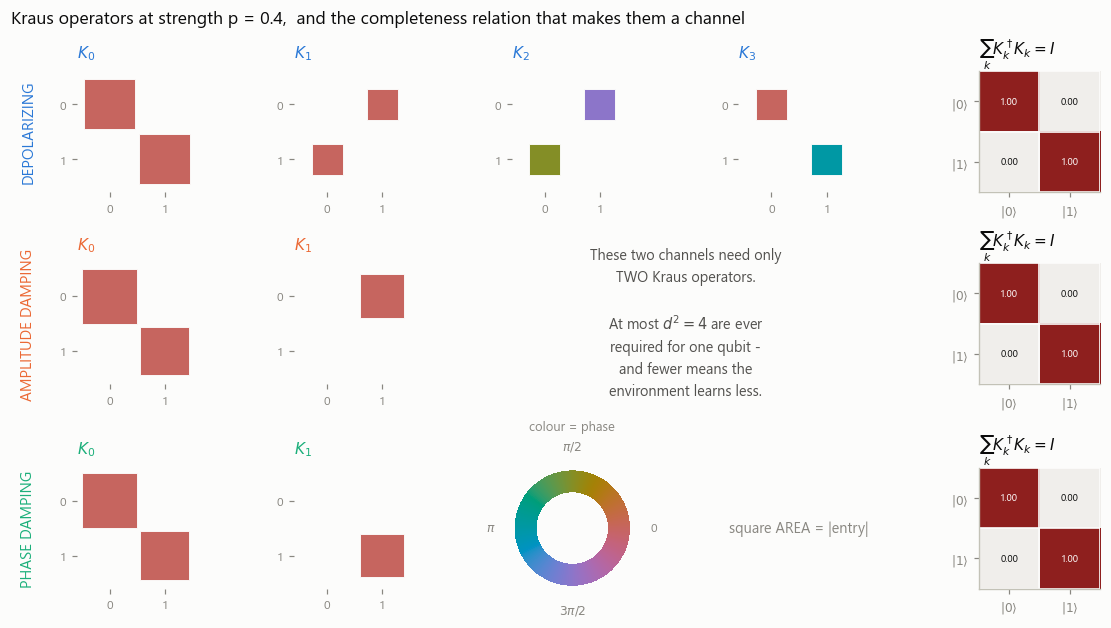

      depolarizing: 4 Kraus operators, max|sum K^dag K - I| = 0.00e+00
 amplitude damping: 2 Kraus operators, max|sum K^dag K - I| = 0.00e+00
     phase damping: 2 Kraus operators, max|sum K^dag K - I| = 0.00e+00


In [8]:
P_SHOW = 0.4

fig = plt.figure(figsize=(10.6, 5.6))
gs = fig.add_gridspec(3, 5, width_ratios=[1, 1, 1, 1, 1.22])

for i, (name, make, col) in enumerate(CHANNELS):
    ks = make(P_SHOW)
    for j, K in enumerate(ks):
        ax = fig.add_subplot(gs[i, j])
        grid.hinton(ax, K, max_weight=1.0)
        ax.set_title(f"$K_{j}$", loc="left", fontsize=10, color=col)
        if j == 0:
            # Channel name down the left edge of its row.
            ax.text(-0.40, 0.5, name.upper(), transform=ax.transAxes,
                    rotation=90, ha="center", va="center", fontsize=10,
                    color=col)
    axs = fig.add_subplot(gs[i, 4])
    grid.matrix(axs, completeness(ks), part="re", cbar=False, vmax=1.0,
                fmt="{:.2f}", hide_zeros=False, labels=KETLAB)
    axs.set_title(r"$\sum_k K_k^\dagger K_k = I$", loc="left", fontsize=10)

# The four blank cells carry the legend and the reason they are blank.
axw = fig.add_subplot(gs[2, 2], projection="polar")
style.phase_wheel(axw, label="colour = phase")

axn = fig.add_subplot(gs[1, 2:4])
axn.axis("off")
axn.text(0.5, 0.5,
         "These two channels need only\n"
         "TWO Kraus operators.\n\n"
         "At most $d^2 = 4$ are ever\n"
         "required for one qubit -\n"
         "and fewer means the\n"
         "environment learns less.",
         ha="center", va="center", fontsize=9.5, color=style.INK_2,
         transform=axn.transAxes, linespacing=1.5)

axe = fig.add_subplot(gs[2, 3])
axe.axis("off")
axe.text(0.5, 0.5, "square AREA = |entry|",
         ha="center", va="center", fontsize=9.5, color=style.MUTED,
         transform=axe.transAxes)

fig.suptitle(f"Kraus operators at strength p = {P_SHOW},  and the completeness "
             "relation that makes them a channel",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

for name, make, _ in CHANNELS:
    ks = make(P_SHOW)
    print(f"{name:>18}: {len(ks)} Kraus operators, "
          f"max|sum K^dag K - I| = {np.max(np.abs(completeness(ks) - I2)):.2e}")

Two things to take from the picture.

**Amplitude damping's $K_1$ is off-diagonal and $K_0$ is not unitary.** Neither
operator alone is a legal evolution; only the pair together is. That is the
structural difference between a channel and a gate, in one glance.

**Depolarizing needs four operators, phase damping two.** The number of Kraus
operators is roughly "how many distinguishable things the environment could learn
about you". At most $d^2 = 4$ are ever needed for one qubit.

## The picture that makes a channel obvious: it deforms the ball

Here is the payoff for the whole Bloch-ball setup.

A channel is linear in $\rho$, and $\rho$ is affine in $r$. So **a channel acts on
the Bloch vector as an affine map**:

$$r \;\longmapsto\; M\,r + t,$$

with $M$ a $3\times3$ real matrix and $t$ a translation. Everything a one-qubit
CPTP map can do is: rotate, squash along three axes, and shift. The ball goes to
an **ellipsoid** inside the ball.

We don't assert $M$ and $t$ — we *measure* them, by pushing the six cardinal
states through the channel and reading off what came out:

$$M_{:,j} = \tfrac12\big(r(\mathcal{E}(\rho_{+e_j})) - r(\mathcal{E}(\rho_{-e_j}))\big),
\qquad t = r\big(\mathcal{E}(I/2)\big).$$

The centre of the ball goes to $t$ because $r = 0$ there; the difference of two
antipodal outputs cancels $t$ and leaves the linear part.

(This $3\times3$ block is the interesting corner of the $4\times4$ **Pauli
transfer matrix**, which B26 draws in full with Qiskit. Here we just need the
geometry.)

In [9]:
def affine_of(kraus):
    """Measure the affine action (M, t) of a channel on the Bloch vector."""
    t = bloch_vector(apply_channel(kraus, I2 / 2))
    M = np.zeros((3, 3))
    for j, e in enumerate(np.eye(3)):
        plus = bloch_vector(apply_channel(kraus, rho_from_bloch(e)))
        minus = bloch_vector(apply_channel(kraus, rho_from_bloch(-e)))
        M[:, j] = 0.5 * (plus - minus)
    return M, t


# Verify the affine model against the channel itself on random states.
worst = 0.0
for name, make, _ in CHANNELS:
    for pv in (0.15, 0.5, 0.85):
        M, t = affine_of(make(pv))
        for _ in range(60):
            rho = random_mixture(rng)
            direct = bloch_vector(apply_channel(make(pv), rho))
            worst = max(worst, np.max(np.abs(direct - (M @ bloch_vector(rho) + t))))
print(f"affine model vs direct Kraus evolution: worst error {worst:.2e}")
print()

for name, make, _ in CHANNELS:
    M, t = affine_of(make(0.6))
    print(f"{name} at p = 0.6")
    print("  M =", np.array2string(np.round(M, 4), prefix="  M = "))
    print("  t =", np.round(t, 4))

affine model vs direct Kraus evolution: worst error 3.33e-16

depolarizing at p = 0.6
  M = [[0.4 0.  0. ]
       [0.  0.4 0. ]
       [0.  0.  0.4]]
  t = [0. 0. 0.]
amplitude damping at p = 0.6
  M = [[0.6325 0.     0.    ]
       [0.     0.6325 0.    ]
       [0.     0.     0.4   ]]
  t = [0.  0.  0.6]
phase damping at p = 0.6
  M = [[0.6325 0.     0.    ]
       [0.     0.6325 0.    ]
       [0.     0.     1.    ]]
  t = [0. 0. 0.]


## Figure 4 — a channel *is* this deformation

Nine panels: three channels down, three strengths across. The dashed grey outline
in every panel is the original unit sphere — equivalently, the $p = 0$ identity
channel, for which the ellipsoid *is* the sphere. The solid shape is where the
ball ends up.

Watch each row on its own and the character of each channel is unmistakable. The
three numbers under each panel are the semi-axes of the ellipsoid and how far its
centre has slid up the $z$ axis.

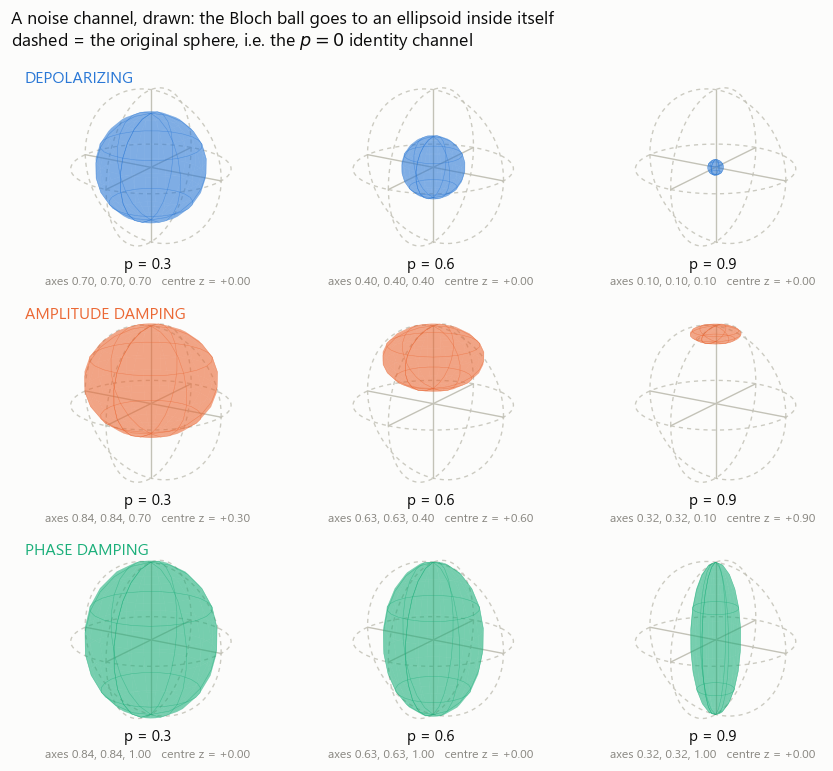

In [10]:
def outline(ax, color=None, lw=0.9):
    """Three great circles: the unit sphere as a 'before' reference."""
    color = color or style.AXIS
    t = np.linspace(0, 2 * np.pi, 120)
    c, s = np.cos(t), np.sin(t)
    zero = np.zeros_like(t)
    for xs, ys, zs in [(c, s, zero), (c, zero, s), (zero, c, s)]:
        ax.plot(xs, ys, zs, color=color, lw=lw, ls=(0, (3, 3)), zorder=1,
                alpha=0.85)


STRENGTHS = [0.3, 0.6, 0.9]

fig = plt.figure(figsize=(7.7, 6.9))
for i, (name, make, col) in enumerate(CHANNELS):
    for j, pv in enumerate(STRENGTHS):
        ax = fig.add_subplot(3, 3, i * 3 + j + 1, projection="3d")
        bloch.sphere(ax, alpha=0.0, wire=False, equator=False, labels=False)
        fill(ax, 1.86)
        outline(ax)
        M, t = affine_of(make(pv))
        bloch.ellipsoid(ax, M, offset=t, color=col, alpha=0.36, n=24)
        sx, sy, sz = np.abs(np.diag(M))
        bloch.label(ax, f"p = {pv:.1f}", y=0.110, size=10)
        bloch.label(ax, f"axes {sx:.2f}, {sy:.2f}, {sz:.2f}   "
                        f"centre z = {t[2]:+.2f}", y=0.022, size=8,
                    color=style.MUTED)
        if j == 0:
            ax.text2D(-0.06, 0.92, name.upper(), transform=ax.transAxes,
                      fontsize=10.5, color=col, ha="left", va="center")
fig.suptitle("A noise channel, drawn: the Bloch ball goes to an ellipsoid "
             "inside itself\ndashed = the original sphere, i.e. the $p=0$ "
             "identity channel",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

Three completely different geometries, and each one *is* the physics:

**Depolarizing shrinks uniformly** and stays centred. Every direction loses the
same fraction, so the ball keeps its shape and just deflates toward $I/2$. At
$p = 1$ it is a point: the qubit has been replaced by a coin flip and every state
maps to the same place. This is the "I have no idea what happened" channel, and it
is the least structured noise there is.

**Amplitude damping shrinks *and slides*.** The $z$ semi-axis shrinks as
$1-\gamma$ while $x, y$ shrink only as $\sqrt{1-\gamma}$ — and the whole thing
drifts up toward $|0\rangle$, which is what the printed `centre z` is telling
you. At $\gamma = 1$ the ellipsoid has collapsed onto the north pole: every state,
pure or mixed, has decayed to $|0\rangle$. It ends **pure**, which is why energy
loss is not the same as randomization.

**Phase damping squashes the equator and leaves the poles alone.** The $z$
semi-axis is exactly 1 at every strength — populations are untouched, forever —
while $x$ and $y$ collapse. The ball becomes a flat disc, then a line segment.
That line segment is precisely the set of classical probability distributions over
$|0\rangle$ and $|1\rangle$: **phase damping is the channel that turns a qubit
into a bit**, and Figure 1's two rows are its endpoints.

If you only remember one picture from this notebook, remember this one. "Noise" is
not a fog; it is a specific, measurable, three-number distortion of a ball.

## Figure 5 — applying a channel over and over

Noise is not a single event; it accrues. Apply the same channel $n$ times and the
affine map composes, so the Bloch vector follows

$$r_n = M^n r_0 + (I + M + \cdots + M^{n-1})\,t,$$

which is a geometric decay toward the channel's fixed point. Start from
$r_0 = \tfrac{1}{\sqrt3}(1,1,1)$ — a state with something on every axis — and
watch.

The left panel is amplitude damping resolved into components: $x$ and $y$ decay at
one rate, $z$ climbs to $+1$ at another. Those two rates are $T_2$ and $T_1$, and
the fact that they are different is why every real device quotes two numbers.
(B26 fits them properly against a Qiskit noise model; here they are just the two
visible slopes.)

The right panel is the honest surprise.

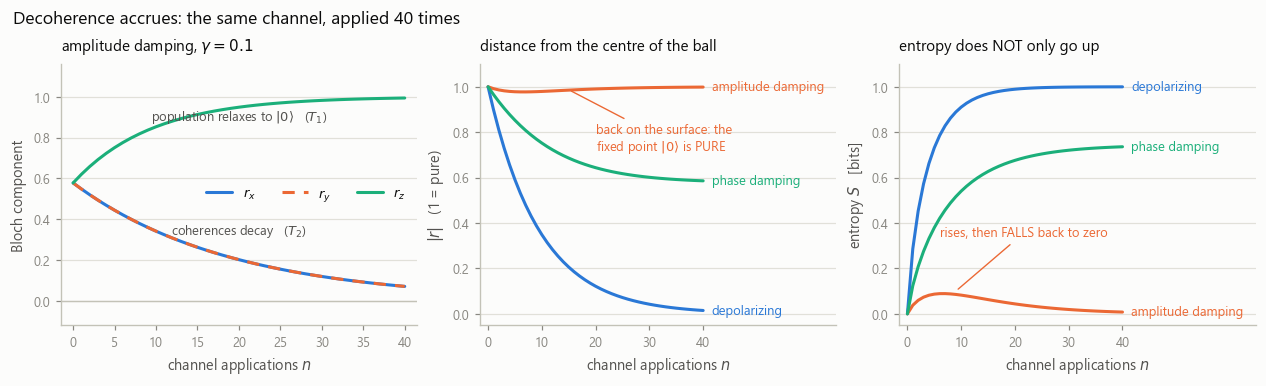

      depolarizing: after 40 steps  |r| = 0.0148   S = 0.9998 bits   r = [0.009 0.009 0.009]
 amplitude damping: after 40 steps  |r| = 0.9987   S = 0.0078 bits   r = [0.07  0.07  0.994]
     phase damping: after 40 steps  |r| = 0.5858   S = 0.7359 bits   r = [0.07  0.07  0.577]


In [11]:
r0 = np.ones(3) / np.sqrt(3)
STEPS = 40
n_axis = np.arange(STEPS + 1)
STRENGTH = {"depolarizing": 0.10, "amplitude damping": 0.10,
            "phase damping": 0.10}

traj = {}
for name, make, col in CHANNELS:
    ks = make(STRENGTH[name])
    rho = rho_from_bloch(r0)
    rs, ss = [bloch_vector(rho)], [entropy(rho)]
    for _ in range(STEPS):
        rho = apply_channel(ks, rho)
        rs.append(bloch_vector(rho))
        ss.append(entropy(rho))
    traj[name] = (np.array(rs), np.array(ss))

fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.4))


def end_labels(ax, series):
    """Label each curve at its right-hand end - no legend, no colour-alone."""
    for name, y_end, col in series:
        ax.text(STEPS + 1.6, y_end, name, color=col, fontsize=8.5,
                ha="left", va="center")
    ax.set_xlim(-1.5, STEPS * 1.62)
    ax.set_xticks([0, 10, 20, 30, 40])


rs, _ = traj["amplitude damping"]
# r_x and r_y decay identically here and would plot exactly on top of one
# another, so r_y is dashed: two curves, both visible, no missing series.
for k, (lab, col, ls) in enumerate([(r"$r_x$", style.BLUE, "-"),
                                    (r"$r_y$", style.ORANGE, (0, (4, 3))),
                                    (r"$r_z$", style.AQUA, "-")]):
    axes[0].plot(n_axis, rs[:, k], color=col, lw=2.0, ls=ls, label=lab)
axes[0].axhline(0, color=style.AXIS, lw=0.9)
axes[0].text(20, 0.86, r"population relaxes to $|0\rangle$   ($T_1$)",
             fontsize=8.5, color=style.INK_2, ha="center", va="bottom")
axes[0].text(20, 0.30, r"coherences decay   ($T_2$)",
             fontsize=8.5, color=style.INK_2, ha="center", va="bottom")
axes[0].set_xlabel("channel applications $n$")
axes[0].set_ylabel("Bloch component")
axes[0].set_ylim(-0.12, 1.16)
axes[0].set_xlim(-1.5, STEPS + 1.5)
axes[0].legend(loc="center right", ncols=3)
axes[0].set_title(r"amplitude damping, $\gamma=0.1$", loc="left", fontsize=10)

for name, make, col in CHANNELS:
    rs, _ = traj[name]
    axes[1].plot(n_axis, np.linalg.norm(rs, axis=1), color=col, lw=2.0)
axes[1].set_xlabel("channel applications $n$")
axes[1].set_ylabel(r"$|r|$   (1 = pure)")
axes[1].set_ylim(-0.05, 1.10)
end_labels(axes[1], [(n, np.linalg.norm(traj[n][0][-1]), c)
                     for n, _, c in CHANNELS])
axes[1].annotate("back on the surface: the\nfixed point $|0\\rangle$ is PURE",
                 xy=(15, 0.987), xytext=(20, 0.72), fontsize=8.5,
                 color=style.ORANGE,
                 arrowprops=dict(arrowstyle="-", color=style.ORANGE, lw=0.9))
axes[1].set_title("distance from the centre of the ball", loc="left",
                  fontsize=10)

for name, make, col in CHANNELS:
    _, ss = traj[name]
    axes[2].plot(n_axis, ss, color=col, lw=2.0)
axes[2].set_xlabel("channel applications $n$")
axes[2].set_ylabel("entropy $S$   [bits]")
axes[2].set_ylim(-0.05, 1.10)
end_labels(axes[2], [(n, traj[n][1][-1], c) for n, _, c in CHANNELS])
axes[2].annotate("rises, then FALLS back to zero",
                 xy=(9, 0.10), xytext=(6, 0.34), fontsize=8.5,
                 color=style.ORANGE,
                 arrowprops=dict(arrowstyle="-", color=style.ORANGE, lw=0.9))
axes[2].set_title("entropy does NOT only go up", loc="left", fontsize=10)

fig.suptitle("Decoherence accrues: the same channel, applied 40 times",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

for name, make, col in CHANNELS:
    rs, ss = traj[name]
    print(f"{name:>18}: after {STEPS} steps  |r| = "
          f"{np.linalg.norm(rs[-1]):.4f}   S = {ss[-1]:.4f} bits   "
          f"r = {np.round(rs[-1], 3)}")

The right-hand panel is worth staring at. Under **amplitude damping** the entropy
climbs to about $0.9$ bits and then comes back down to **zero**. The qubit passes
through maximum ignorance and comes out the other side in a perfectly known state,
$|0\rangle$.

That is not a violation of anything — the entropy went into the environment, which
now holds a photon that says "it decayed". It *is* a useful corrective to the
folklore that noise means entropy increase. What noise destroys is **your
information about the state relative to the computation you wanted**, and a
qubit reliably reset to $|0\rangle$ is useless for computing while being perfectly
pure. Depolarizing, by contrast, marches monotonically to 1 bit and stays there.

Phase damping stalls: its $|r|$ flattens at the $z$-component it started with,
because that component is a fixed point. It converts a qubit into a bit and then
leaves the bit alone.

## Partial trace: where mixed states actually come from

Everything so far has treated mixture as ignorance about a preparation. There is a
second, deeper source, and it needs no ignorance at all.

Take a **pure, perfectly known** two-qubit state and ask "what is the state of
qubit 0 alone?". The answer is the **partial trace** over qubit 1:

$$\rho_0 = \mathrm{Tr}_1\big(\rho_{01}\big),
\qquad (\rho_0)_{ab} = \sum_{c} \langle c\,a|\rho_{01}|c\,b\rangle.$$

It is the unique operation that gets local measurement statistics right: any
measurement on qubit 0 alone gives the same answer computed from $\rho_0$ as from
the full $\rho_{01}$.

### Endianness, carefully

This repo is **little-endian**: in the label `b1 b0`, qubit 0 is the *rightmost*
character, and basis index $i = 2b_1 + b_0$. So `np.kron(a, b)` puts `a` on
**qubit 1** and `b` on **qubit 0** — qubit 0 is the *last* Kronecker factor, as in
A05 and A06.

Partial trace is where a silent endianness bug is most likely, because tracing the
wrong subsystem still returns a perfectly legal-looking $2\times2$ matrix. So
`partial_trace` below takes the qubit indices to **keep**, reshapes to one axis
per qubit in descending order, and traces the axis pair belonging to the qubit
being removed. The asserts underneath check it against a state where the two
qubits are obviously different: $|0\rangle$ on qubit 1 and $|1\rangle$ on qubit 0
must reduce to $|1\rangle\langle1|$ on qubit 0 and $|0\rangle\langle0|$ on qubit
1, not the other way round.

In [12]:
def partial_trace(rho, keep, n):
    """Trace out every qubit not in `keep`. Little-endian throughout.

    rho is (2**n, 2**n). Reshaping to [2]*2n gives axes ordered
    (qubit n-1, ..., qubit 0) for the row index, then the same for the column,
    because index i = sum_q b_q 2**q puts qubit n-1 in the MOST significant slot.
    """
    keep = sorted(keep)
    t = np.asarray(rho).reshape([2] * (2 * n))
    order = list(range(n - 1, -1, -1))          # axis position -> qubit index
    for q in [q for q in range(n) if q not in keep]:
        ax = order.index(q)
        t = np.trace(t, axis1=ax, axis2=ax + len(order))
        order.pop(ax)
    d = 2 ** len(order)
    return t.reshape(d, d)


def label2(i):
    return format(i, "02b")


# |0> on qubit 1, |1> on qubit 0  ->  index 2*0 + 1 = 1, printed |01>.
psi_01 = np.kron(KET0, KET1)
assert int(np.argmax(np.abs(psi_01))) == 1, "little-endian ordering broken"
rho_01 = dm(psi_01)
assert np.allclose(partial_trace(rho_01, keep=[0], n=2), dm(KET1))
assert np.allclose(partial_trace(rho_01, keep=[1], n=2), dm(KET0))

# A product state with different, non-orthogonal factors, to be sure.
psi_prod = np.kron(KET0, PLUS)               # qubit 1 = |0>, qubit 0 = |+>
rho_prod = dm(psi_prod)
assert np.allclose(partial_trace(rho_prod, keep=[0], n=2), dm(PLUS))
assert np.allclose(partial_trace(rho_prod, keep=[1], n=2), dm(KET0))

# The Bell state (|00> + |11>)/sqrt(2).
psi_bell = (np.kron(KET0, KET0) + np.kron(KET1, KET1)) / np.sqrt(2)
rho_bell = dm(psi_bell)

print("state           index -> label      reduced rho_0 diagonal")
for name, psi in [("|01>", psi_01), ("|0+>", psi_prod), ("Bell", psi_bell)]:
    r0 = partial_trace(dm(psi), keep=[0], n=2)
    top = int(np.argmax(np.abs(psi)))
    print(f"  {name:<12} {top} -> |{label2(top)}>          "
          f"{np.round(np.diag(r0).real, 4)}")
print()
for name, psi in [("product |0+>", psi_prod), ("Bell", psi_bell)]:
    rho = dm(psi)
    r0 = partial_trace(rho, keep=[0], n=2)
    print(f"{name:>14}:  joint purity {purity(rho):.4f}, joint S "
          f"{entropy(rho):.4f} bits")
    print(f"{'':>14}   reduced purity {purity(r0):.4f}, reduced S "
          f"{entropy(r0):.4f} bits, |r| = "
          f"{np.linalg.norm(bloch_vector(r0)):.4f}")

state           index -> label      reduced rho_0 diagonal
  |01>         1 -> |01>          [0. 1.]
  |0+>         0 -> |00>          [0.5 0.5]
  Bell         0 -> |00>          [0.5 0.5]

  product |0+>:  joint purity 1.0000, joint S 0.0000 bits
                 reduced purity 1.0000, reduced S 0.0000 bits, |r| = 1.0000
          Bell:  joint purity 1.0000, joint S 0.0000 bits
                 reduced purity 0.5000, reduced S 1.0000 bits, |r| = 0.0000


## Figure 6 — entanglement's fingerprint

Both rows below start from a **pure, fully known** two-qubit state — joint entropy
exactly 0 bits, nothing hidden, no ignorance anywhere.

Top row: the product state $|0\rangle_1 \otimes |+\rangle_0$. Trace out qubit 1
and qubit 0 is still $|+\rangle$, still pure, still on the surface of the ball.

Bottom row: the Bell state $\tfrac{1}{\sqrt2}(|00\rangle + |11\rangle)$. Trace out
qubit 1 and qubit 0 is $I/2$ — the **dead centre** of the ball, 1 full bit of
entropy, maximally mixed. Measure it in any basis whatsoever and get a fair coin.

Nobody was ignorant of anything. The information didn't go missing; it was never
stored locally. In the Bell state, everything there is to know is a **correlation
between** the two qubits, and the partial trace throws the correlation away
because it asks a question — "what is qubit 0 doing on its own?" — that the state
does not have a pure answer to.

That is the sharpest one-line definition of entanglement available:
**a pure joint state whose parts are mixed.**

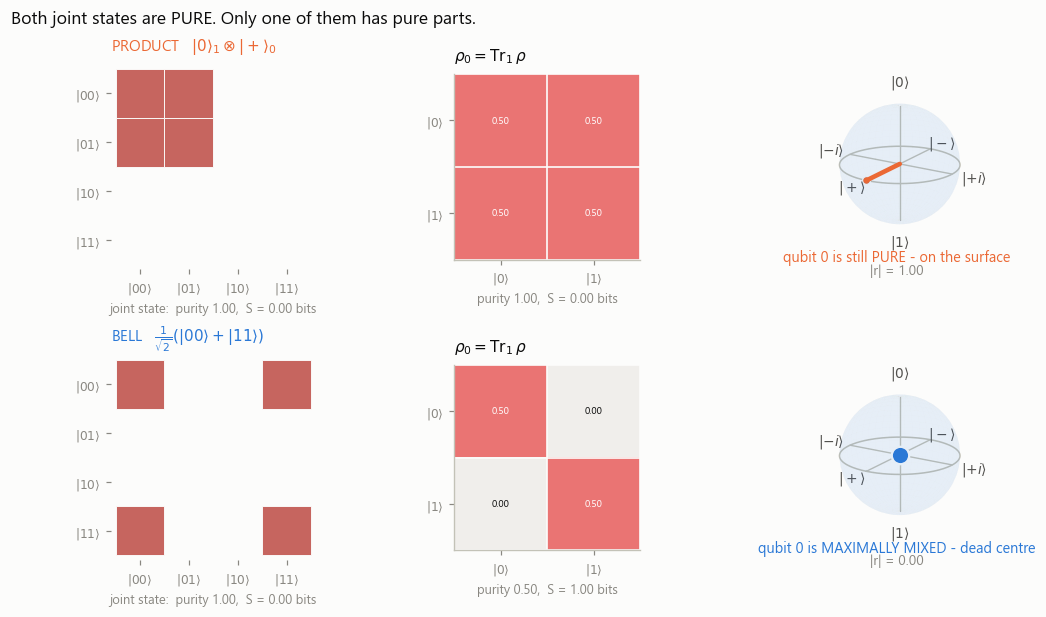

Bell: reduced state on qubit 0 =
[[0.5 0. ]
 [0.  0.5]]
...and on qubit 1 =
[[0.5 0. ]
 [0.  0.5]]

entanglement entropy of the Bell state: 1.0 bit


In [13]:
cases = [("PRODUCT   " + r"$|0\rangle_1 \otimes |+\rangle_0$",
          rho_prod, style.ORANGE),
         ("BELL   " + r"$\frac{1}{\sqrt{2}}(|00\rangle+|11\rangle)$",
          rho_bell, style.BLUE)]

fig = plt.figure(figsize=(10.4, 5.5))
gs = fig.add_gridspec(2, 3, width_ratios=[0.92, 0.42, 1.12])

for i, (name, rho, col) in enumerate(cases):
    axj = fig.add_subplot(gs[i, 0])
    grid.hinton(axj, rho, max_weight=0.5,
                labels=[r"$|00\rangle$", r"$|01\rangle$", r"$|10\rangle$",
                        r"$|11\rangle$"])
    axj.set_title(name, loc="left", fontsize=10, color=col)
    axj.set_xlabel(f"joint state:  purity {purity(rho):.2f},  "
                   f"S = {entropy(rho):.2f} bits", fontsize=8.5,
                   color=style.MUTED)

    r0 = partial_trace(rho, keep=[0], n=2)
    axr = fig.add_subplot(gs[i, 1])
    grid.matrix(axr, r0, part="re", cbar=False, vmax=1.0, fmt="{:.2f}",
                hide_zeros=False, labels=KETLAB)
    axr.set_title(r"$\rho_0 = \mathrm{Tr}_1\,\rho$", loc="left", fontsize=10)
    axr.set_xlabel(f"purity {purity(r0):.2f},  S = {entropy(r0):.2f} bits",
                   fontsize=8.5, color=style.MUTED)

    ax = fig.add_subplot(gs[i, 2], projection="3d")
    bloch.sphere(ax, alpha=0.05, wire=False)
    fill(ax, 1.5)
    v = bloch_vector(r0)
    if np.linalg.norm(v) > 1e-9:
        bloch.vector(ax, v, color=col, lw=3.0)
        tag = "qubit 0 is still PURE - on the surface"
    else:
        ax.scatter([0], [0], [0], s=130, color=col, depthshade=False,
                   edgecolors=style.SURFACE, linewidths=1.5, zorder=9)
        tag = "qubit 0 is MAXIMALLY MIXED - dead centre"
    bloch.label(ax, tag, y=0.10, size=9.5, color=col)
    bloch.label(ax, f"|r| = {np.linalg.norm(v):.2f}", y=0.03, size=9,
                color=style.MUTED)

fig.suptitle("Both joint states are PURE. Only one of them has pure parts.",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

print("Bell: reduced state on qubit 0 =")
print(np.round(partial_trace(rho_bell, keep=[0], n=2).real, 6))
print("...and on qubit 1 =")
print(np.round(partial_trace(rho_bell, keep=[1], n=2).real, 6))
print()
print("entanglement entropy of the Bell state:",
      round(entropy(partial_trace(rho_bell, keep=[0], n=2)), 12), "bit")

Look at the Hinton diagrams in column 1. The Bell state's four squares sit at
$|00\rangle\langle00|$, $|00\rangle\langle11|$, $|11\rangle\langle00|$ and
$|11\rangle\langle11|$ — two populations and two big **coherences between the two
qubits**. After the partial trace, the reduced matrix in column 2 is diagonal: the
coherences were never local, so tracing out the partner deletes them.

That is also why an entangled qubit is so fragile. The information holding it
together lives in a correlation, and a channel acting on *either* half is enough to
break it. C27 is the counter-attack: spread the information over enough qubits
that no single local channel can find all of it.

## Honest limits

**The Bloch ball is a one-qubit luxury, and there is no honest two-qubit
version.** A one-qubit $\rho$ has 3 real parameters, which fit in 3 dimensions;
that is the *only* reason this notebook has such good pictures. A two-qubit $\rho$
has 15, and the set of legal ones is a lumpy 15-dimensional convex body that
nobody can draw. The tempting workaround is to draw one little ball per qubit
using the reduced states — which is exactly what Qiskit's `plot_bloch_multivector`
does, and Figure 6 has just shown you why it **lies about entanglement**: it draws
the Bell state as two sad dots at the origin, identical to what it draws for two
independently-depolarized qubits. Same picture, completely different physics. B14
puts those two side by side.

**Kraus decompositions are not unique.** The operators in Figure 3 are *a* valid
description of each channel, not *the* description. Any isometric remixing
$K'_j = \sum_k u_{jk} K_k$ gives literally the same channel — the cell below
builds a scrambled amplitude-damping pair and shows the outputs agree to $10^{-16}$
on random inputs. So you cannot read a physical story off the Kraus operators;
"the qubit emitted a photon" is one narration of amplitude damping, not a fact
about it. The **Choi matrix** and the Pauli transfer matrix are the canonical,
decomposition-independent representations, and B26 uses the latter.

**All of this is Markovian.** Every channel here is memoryless: applying it twice
is the same map twice, with no dependence on history, which is why Figure 5's
composition was just $M^n$. Real devices are only approximately like that. They
have $1/f$ noise, drift over hours, crosstalk that correlates errors across
qubits, and non-Markovian back-action where the environment gives energy *back*.
A non-Markovian channel can make entropy go *down* in ways the memoryless model
forbids. Everything here is the right first model and the wrong last word.

**Density matrices scale worse than statevectors.** A pure $n$-qubit state is
$2^n$ numbers; its density matrix is $4^n$. At 15 qubits that is a billion complex
entries, 16 GB, for a state a statevector simulator holds in 512 KB. This is why
Aer keeps `statevector` and `density_matrix` as separate methods, and why noisy
simulation is done by sampling trajectories (apply a random Kraus operator per
shot, average over shots) rather than by propagating $\rho$. A07's exponential
wall, squared.

**The channels here are toy strengths, not device parameters.** $p = 0.4$ per gate
would be a catastrophically bad qubit. Real single-qubit error rates are $10^{-4}$
to $10^{-3}$, two-qubit rates around $10^{-2}$; the figures use large values
because a 0.1% ellipsoid is visually indistinguishable from a sphere. B26 works
with realistic $T_1$, $T_2$ numbers.

**Purity and entropy are not entanglement measures beyond two parties.** For a
*pure* bipartite state, the reduced entropy is the entanglement entropy and it is
the right answer. For a mixed joint state it is not — a separable mixed state can
have high reduced entropy for entirely classical reasons. A06's Schmidt-rank
warning applies here too: deciding whether a mixed state is entangled is genuinely
hard, and needs something like the PPT criterion.

In [14]:
# Kraus non-uniqueness, demonstrated: remix the operators with a unitary.
def remix(kraus, u):
    """K'_j = sum_k u[j,k] K_k. Preserves the channel whenever u is unitary."""
    return [sum(u[j, k] * K for k, K in enumerate(kraus))
            for j in range(u.shape[0])]


theta = 0.7
u = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta), np.cos(theta)]], dtype=complex)
orig = amplitude_damping(0.35)
scrambled = remix(orig, u)

print("original K_0, K_1:")
for K in orig:
    print(np.round(K.real, 4))
print("remixed K'_0, K'_1 (completely different matrices):")
for K in scrambled:
    print(np.round(K.real, 4))
print()
print("still complete? max|sum K'^dag K' - I| =",
      f"{np.max(np.abs(completeness(scrambled) - I2)):.2e}")

worst = 0.0
for _ in range(300):
    rho = random_mixture(rng)
    worst = max(worst, np.max(np.abs(apply_channel(orig, rho)
                                     - apply_channel(scrambled, rho))))
print(f"same channel on 300 random inputs? worst difference {worst:.2e}")
print()
print("Two different lists of matrices. One physical map. There is no")
print("experiment that can tell you which list 'really' happened.")

original K_0, K_1:
[[1.     0.    ]
 [0.     0.8062]]
[[0.     0.5916]
 [0.     0.    ]]
remixed K'_0, K'_1 (completely different matrices):
[[ 0.7648 -0.3811]
 [ 0.      0.6166]]
[[0.6442 0.4525]
 [0.     0.5194]]

still complete? max|sum K'^dag K' - I| = 2.22e-16


same channel on 300 random inputs? worst difference 3.33e-16

Two different lists of matrices. One physical map. There is no
experiment that can tell you which list 'really' happened.


## Checkpoint

Analytic ground truth, asserted. Every number below is one you could derive with a
pen; if the code drifts, this cell fails.

In [15]:
# 1. Every rho we built is a legal density matrix: Hermitian, PSD, unit trace.
ALL_RHO = [RHO_SUP, RHO_MIX, I2 / 2, dm(KET0), dm(PLUS), rho_prod, rho_bell,
           partial_trace(rho_bell, keep=[0], n=2)]
for r in ALL_RHO:
    assert np.allclose(r, r.conj().T, atol=1e-14)              # Hermitian
    assert np.min(np.linalg.eigvalsh(r)) > -1e-14              # PSD
    assert np.isclose(np.trace(r).real, 1.0, atol=1e-14)       # unit trace
    assert abs(np.trace(r).imag) < 1e-14
for _ in range(200):
    assert is_density_matrix(random_mixture(rng), tol=1e-10)

# 2. The confrontation: identical in Z, maximally different in X.
assert np.allclose(probs_in_basis(RHO_SUP, Z_BASIS), [0.5, 0.5])
assert np.allclose(probs_in_basis(RHO_MIX, Z_BASIS), [0.5, 0.5])
assert np.allclose(probs_in_basis(RHO_SUP, X_BASIS), [1.0, 0.0], atol=1e-14)
assert np.allclose(probs_in_basis(RHO_MIX, X_BASIS), [0.5, 0.5])
assert not np.allclose(RHO_SUP, RHO_MIX)

# 3. rho forgets the recipe: three different mixtures, one matrix, exactly I/2.
assert np.allclose(mix([0.5, 0.5], [KET0, KET1]), I2 / 2, atol=1e-14)
assert np.allclose(mix([0.5, 0.5], [PLUS, MINUS]), I2 / 2, atol=1e-14)
assert np.allclose(mix([0.5, 0.5], [KET_PI, KET_MI]), I2 / 2, atol=1e-14)

# 4. Purity and entropy at the two extremes, and the closed forms in between.
assert np.isclose(purity(dm(PLUS)), 1.0, atol=1e-14)
assert np.isclose(entropy(dm(PLUS)), 0.0, atol=1e-12)
assert np.isclose(purity(I2 / 2), 0.5, atol=1e-14)
assert np.isclose(entropy(I2 / 2), 1.0, atol=1e-14)
for _ in range(300):
    rho = random_mixture(rng)
    r = bloch_vector(rho)
    assert np.linalg.norm(r) <= 1.0 + 1e-12                       # inside the ball
    assert np.allclose(rho_from_bloch(r), rho, atol=1e-14)        # round trip
    assert np.isclose(purity(rho), (1 + np.linalg.norm(r) ** 2) / 2, atol=1e-14)
    assert -1e-12 <= entropy(rho) <= 1.0 + 1e-12

# 5. Kraus completeness to 1e-12, for every channel at every strength.
for _, make, _ in CHANNELS:
    for pv in np.linspace(0, 1, 51):
        assert np.max(np.abs(completeness(make(pv)) - I2)) < 1e-12

# 6. Channels are trace preserving and positive on random inputs.
for _, make, _ in CHANNELS:
    for pv in (0.13, 0.51, 0.88):
        ks = make(pv)
        for _ in range(40):
            out = apply_channel(ks, random_mixture(rng))
            assert np.isclose(np.trace(out).real, 1.0, atol=1e-12)
            assert np.min(np.linalg.eigvalsh(out)) > -1e-12

# 7. The affine picture is exact, not a cartoon.
for _, make, _ in CHANNELS:
    for pv in (0.2, 0.55, 0.9):
        M, t = affine_of(make(pv))
        for _ in range(40):
            rho = random_mixture(rng)
            assert np.allclose(bloch_vector(apply_channel(make(pv), rho)),
                               M @ bloch_vector(rho) + t, atol=1e-13)

# 8. Each channel's signature geometry, checked against the closed form.
for pv in (0.0, 0.25, 0.6, 0.95):
    Md, td = affine_of(depolarizing(pv))
    assert np.allclose(Md, (1 - pv) * np.eye(3), atol=1e-13)
    assert np.allclose(td, 0.0, atol=1e-13)                       # stays centred

    Ma, ta = affine_of(amplitude_damping(pv))
    assert np.allclose(np.diag(Ma), [np.sqrt(1 - pv), np.sqrt(1 - pv), 1 - pv],
                       atol=1e-13)
    assert np.allclose(ta, [0, 0, pv], atol=1e-13)                # slides to |0>

    Mp, tp = affine_of(phase_damping(pv))
    assert np.allclose(np.diag(Mp), [np.sqrt(1 - pv), np.sqrt(1 - pv), 1.0],
                       atol=1e-13)
    assert np.allclose(tp, 0.0, atol=1e-13)                       # poles fixed

# 9. Fixed points: depolarizing -> I/2 (mixed); amplitude damping -> |0> (pure).
rho = dm(PLUS)
for _ in range(400):
    rho = apply_channel(depolarizing(0.2), rho)
assert np.allclose(rho, I2 / 2, atol=1e-9)
rho = dm(PLUS)
for _ in range(400):
    rho = apply_channel(amplitude_damping(0.2), rho)
assert np.allclose(rho, dm(KET0), atol=1e-9)
assert np.isclose(purity(rho), 1.0, atol=1e-9)      # damping ends PURE

# 10. Kraus decompositions are not unique.
assert not np.allclose(orig[0], scrambled[0])
for _ in range(50):
    rho = random_mixture(rng)
    assert np.allclose(apply_channel(orig, rho), apply_channel(scrambled, rho),
                       atol=1e-14)

# 11. Partial trace, with the endianness pinned down.
assert np.allclose(partial_trace(dm(np.kron(KET0, KET1)), keep=[0], n=2), dm(KET1))
assert np.allclose(partial_trace(dm(np.kron(KET0, KET1)), keep=[1], n=2), dm(KET0))
assert np.allclose(partial_trace(rho_prod, keep=[0], n=2), dm(PLUS))
# ...and it reproduces local measurement statistics computed on the FULL state.
# An operator on qubit 0 is the LAST Kronecker factor (little-endian).
for joint in (rho_prod, rho_bell):
    for basis in (Z_BASIS, X_BASIS, Y_BASIS):
        local = probs_in_basis(partial_trace(joint, keep=[0], n=2), basis)
        full = np.array([float(np.trace(joint @ np.kron(I2, dm(b))).real)
                         for b in basis])
        assert np.allclose(local, full, atol=1e-14)

# 12. THE punchline: a pure joint state with a maximally mixed part.
assert np.isclose(purity(rho_bell), 1.0, atol=1e-14)           # joint state pure
assert np.isclose(entropy(rho_bell), 0.0, atol=1e-12)          # 0 bits jointly
red = partial_trace(rho_bell, keep=[0], n=2)
assert np.allclose(red, I2 / 2, atol=1e-14)
assert np.isclose(purity(red), 0.5, atol=1e-14)                # purity 1/2
assert np.isclose(entropy(red), 1.0, atol=1e-14)               # exactly 1 bit
assert np.allclose(bloch_vector(red), 0.0, atol=1e-14)         # dead centre
assert np.allclose(partial_trace(rho_bell, keep=[1], n=2), I2 / 2, atol=1e-14)
# The product state's part stays pure - that is the contrast.
assert np.isclose(purity(partial_trace(rho_prod, keep=[0], n=2)), 1.0, atol=1e-14)

print("A12 checkpoint passed.")

A12 checkpoint passed.


---

That closes Track A. Twelve notebooks ago a qubit was two complex numbers; it is
now a point in a ball, pushed around by affine maps, entangled with things whose
state it partly *is*. Every line of it was NumPy you could have written yourself,
and nothing was a black box.

**Next:** [B13 — Qiskit Tour: Circuits, Statevector, Operator](B13_Qiskit_Tour.ipynb).
Track B rebuilds all of this with the SDK you would actually use at work — and
every Track B notebook ends by asserting `np.allclose` against the Track A result
it mirrors, so the two halves keep each other honest. For this notebook's material
specifically, **B26** draws the Pauli transfer matrix — the decomposition-free
$4\times4$ portrait of a channel that Figure 4 was a shadow of — and fits real
$T_1$/$T_2$ decay curves against a hardware noise model.